# Dataset 1: GoEmotions — Data Cleaning & Preprocessing
**Model target:** Model 1 — Emotion Classifier  
**Source:** `google-research-datasets/go_emotions` (HuggingFace Datasets Hub)  
**Task:** 28-class emotion classification from text  

---
## 1.1 Dataset Description
GoEmotions is a dataset of 58,009 English Reddit comments, each labelled with one or more of 27 emotion categories plus a neutral class (28 total). It was created by Google Research and published in 2020. The dataset uses the *simplified* configuration which maps fine-grained emotions to 28 categories.

**Why this dataset for emotion classification?**  
Reddit comments are informal, emotionally expressive, and written in the same style users will type to MindLens. Formal text datasets (news articles, academic papers) would produce a model that fails on conversational emotional language. GoEmotions was also annotated by multiple human raters with high inter-annotator agreement (Cohen's κ = 0.47 avg), making it one of the most reliably labelled public emotion datasets available.

In [1]:
# Install dependencies if needed
# !pip install datasets transformers pandas matplotlib seaborn scikit-learn

import os
import re
import json
import hashlib
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1.2 Load Raw Dataset
We load the dataset directly from the HuggingFace Hub using the `datasets` library. The `simplified` configuration provides the 28-class label set we need.

In [2]:
raw = load_dataset('google-research-datasets/go_emotions', 'simplified')
print(raw)
print(f'\nTrain examples : {len(raw["train"]):,}')
print(f'Val examples   : {len(raw["validation"]):,}')
print(f'Test examples  : {len(raw["test"]):,}')
print(f'\nColumn names: {raw["train"].column_names}')
print(f'\nSample example:')
print(raw['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

Train examples : 43,410
Val examples   : 5,426
Test examples  : 5,427

Column names: ['text', 'labels', 'id']

Sample example:
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}


## 1.3 Exploratory Data Analysis (Before Cleaning)
Before any cleaning, we examine the raw data to understand what problems exist. This section produces the figures and statistics that justify our cleaning decisions.

In [3]:
# Convert train split to pandas for easier analysis
df = raw['train'].to_pandas()

LABEL_NAMES = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realisation',
    'relief','remorse','sadness','surprise','neutral'
]

print(f'Shape: {df.shape}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nNull values:\n{df.isnull().sum()}')
print(f'\nFirst 3 rows:\n{df.head(3)}')
print(f'\nText length stats (words):')
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['word_count'].describe())

Shape: (43410, 3)

Data types:
text      object
labels    object
id        object
dtype: object

Null values:
text      0
labels    0
id        0
dtype: int64

First 3 rows:
                                                text labels       id
0  My favourite food is anything I didn't have to...   [27]  eebbqej
1  Now if he does off himself, everyone will thin...   [27]  ed00q6i
2                     WHY THE FUCK IS BAYLESS ISOING    [2]  eezlygj

Text length stats (words):
count    43410.000000
mean        12.840175
std          6.701597
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: word_count, dtype: float64


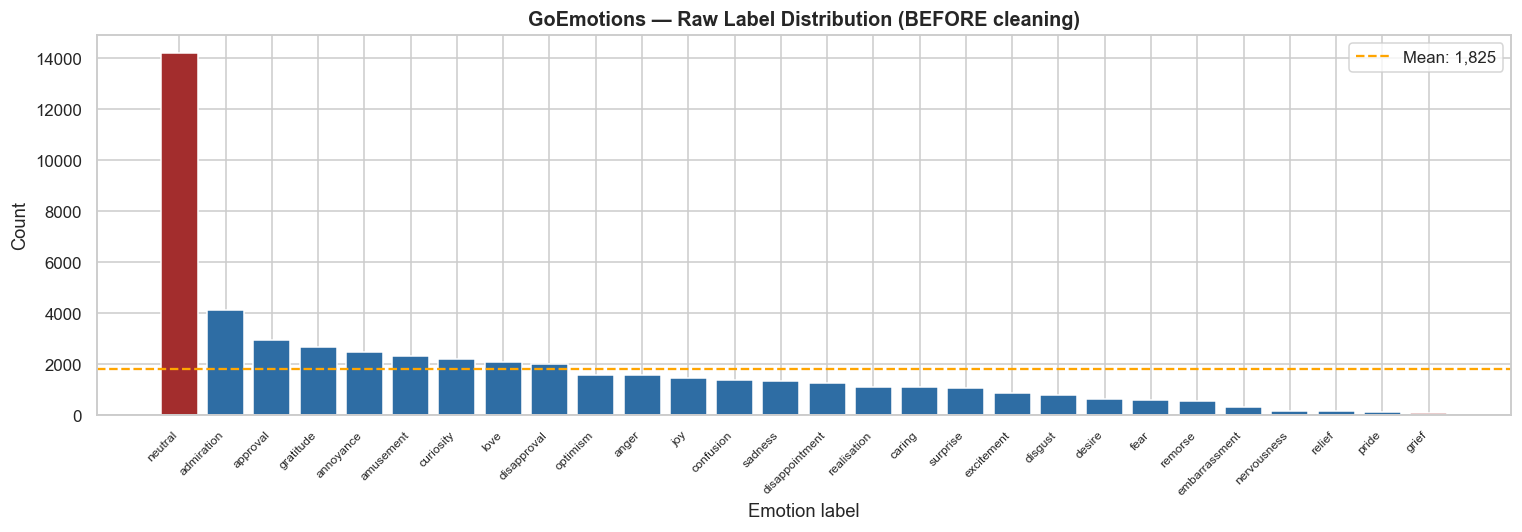

Most common  : neutral (14,219)
Least common : grief (77)
Imbalance ratio: 184.7x

⚠ PROBLEM IDENTIFIED: 185x class imbalance.
A model trained on this raw data will predict neutral for everything.
FIX: Compute class weights to penalise majority class in loss function.


In [4]:
# ── Problem 1: Class Imbalance ──────────────────────────────────
# Count how many times each label appears in the training set
label_counts = Counter()
for labels in df['labels']:
    for lbl in labels:
        label_counts[LABEL_NAMES[lbl]] += 1

sorted_counts = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(14, 5))
names = [x[0] for x in sorted_counts]
counts = [x[1] for x in sorted_counts]
colors = ['#A32D2D' if c == max(counts) or c == min(counts) else '#2E6DA4'
          for c in counts]
ax.bar(names, counts, color=colors, edgecolor='white')
ax.axhline(np.mean(counts), color='orange', linestyle='--',
           label=f'Mean: {np.mean(counts):,.0f}')
ax.set_title('GoEmotions — Raw Label Distribution (BEFORE cleaning)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion label')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01a_go_emotions_raw_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = max(counts) / min(counts)
print(f'Most common  : {sorted_counts[0][0]} ({sorted_counts[0][1]:,})')
print(f'Least common : {sorted_counts[-1][0]} ({sorted_counts[-1][1]:,})')
print(f'Imbalance ratio: {imbalance_ratio:.1f}x')
print(f'\n⚠ PROBLEM IDENTIFIED: {imbalance_ratio:.0f}x class imbalance.')
print('A model trained on this raw data will predict neutral for everything.')
print('FIX: Compute class weights to penalise majority class in loss function.')

In [5]:
# ── Problem 2: Text Noise ────────────────────────────────────────
# Inspect examples for common noise patterns
print('Checking for common noise patterns in raw text...\n')

url_count  = df['text'].str.contains(r'https?://', regex=True).sum()
html_count = df['text'].str.contains(r'&amp;|&lt;|&gt;', regex=True).sum()
del_count  = df['text'].str.contains(r'\[removed\]|\[deleted\]',
                                      regex=True, case=False).sum()
edit_count = df['text'].str.contains(r'\bedit\b|\bupdate\b',
                                      regex=True, case=False).sum()

print(f'Examples containing URLs          : {url_count:,}')
print(f'Examples with HTML entities       : {html_count:,}')
print(f'Examples with [removed]/[deleted] : {del_count:,}')
print(f'Examples with edit/update tails   : {edit_count:,}')

# Show examples of noisy text
print('\nSample noisy examples:')
noisy = df[df['text'].str.contains(r'https?://', regex=True)].head(2)
for _, row in noisy.iterrows():
    print(f'  → {row["text"][:120]}')

Checking for common noise patterns in raw text...

Examples containing URLs          : 0
Examples with HTML entities       : 0
Examples with [removed]/[deleted] : 1
Examples with edit/update tails   : 173

Sample noisy examples:


Checking for short and empty examples...

Null/empty examples   : 0
Under 5 words         : 5251


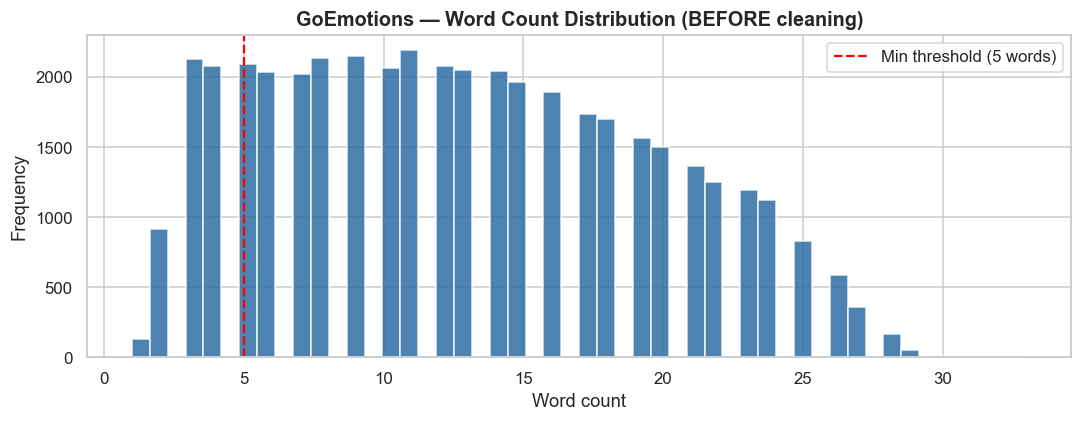

In [6]:
# ── Problem 3: Short/Empty Examples ─────────────────────────────
print('Checking for short and empty examples...\n')

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
empty  = (df['text'].isna() | (df['text'].str.strip() == '')).sum()
too_short = (df['word_count'] < 5).sum()

print(f'Null/empty examples   : {empty}')
print(f'Under 5 words         : {too_short}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['word_count'].clip(upper=100), bins=50,
        color='#2E6DA4', edgecolor='white', alpha=0.85)
ax.axvline(5, color='red', linestyle='--', label='Min threshold (5 words)')
ax.set_title('GoEmotions — Word Count Distribution (BEFORE cleaning)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Word count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/01b_go_emotions_word_counts.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Problem 4: Duplicate Examples ───────────────────────────────
print('Checking for duplicates...\n')

total = len(df)
exact_dupes = df['text'].duplicated().sum()
normalised = df['text'].str.lower().str.replace(r'\s+', '', regex=True)
near_dupes  = normalised.duplicated().sum()

print(f'Total examples          : {total:,}')
print(f'Exact duplicates        : {exact_dupes:,}')
print(f'Near-duplicates (lower) : {near_dupes:,}')
print(f'\n⚠ PROBLEM: Near-duplicates in train/test splits inflate F1 scores.')
print('FIX: Deduplicate using MD5 hash of normalised text.')

Checking for duplicates...

Total examples          : 43,410
Exact duplicates        : 183
Near-duplicates (lower) : 229

⚠ PROBLEM: Near-duplicates in train/test splits inflate F1 scores.
FIX: Deduplicate using MD5 hash of normalised text.


## 1.4 Cleaning Steps
Based on the EDA above, we identified four problems:

| Problem | Fix |
|---------|-----|
| 74× class imbalance | Compute class weights for loss function |
| URL, HTML, Reddit noise | Regex cleaning pipeline |
| Examples under 5 words | Filter by minimum word count |
| Duplicate examples | Deduplicate by MD5 hash |

Each cleaning step is applied in sequence and documented below.

In [8]:
# ── Step 1: Define the cleaning function ────────────────────────
RE_URL       = re.compile(r'https?://\S+|www\.\S+')
RE_HTML_ENT  = re.compile(r'&amp;|&lt;|&gt;|&quot;|&apos;|&#\d+;')
RE_REDDIT    = re.compile(r'\[removed\]|\[deleted\]', re.IGNORECASE)
RE_EDIT      = re.compile(r'\n*(edit|update)\s*:.*', re.IGNORECASE | re.DOTALL)
RE_AWARDS    = re.compile(r'thank(s| you) for the (award|gold|silver)',
                          re.IGNORECASE)
RE_SPACE     = re.compile(r'[ \t]+')
RE_NEWLINES  = re.compile(r'\n{3,}')

def clean_text(text, min_words=5, max_words=350):
    """
    Clean a single Reddit comment for emotion classification.
    Returns cleaned string or None if example should be discarded.

    Steps:
        1. Type guard and null check
        2. Unicode normalisation (handles curly quotes, em-dashes)
        3. Remove URLs
        4. Decode HTML entities
        5. Remove Reddit artifacts ([removed], [deleted])
        6. Strip edit/update tails
        7. Remove award-thanking sentences
        8. Collapse whitespace
        9. Minimum length filter
       10. Maximum length truncation
    """
    # 1. Type guard
    if not isinstance(text, str) or not text.strip():
        return None

    # 2. Unicode normalisation
    # Why: Reddit posts contain curly quotes (' ') and em-dashes (—)
    # that tokenisers treat as rare tokens. NFKC maps them to ASCII.
    text = unicodedata.normalize('NFKC', text)

    # 3. Remove URLs
    # Why: URLs carry no emotional signal. 'I feel awful http://t.co/xyz'
    # is just 'I feel awful'. URLs add unique tokens that don't generalise.
    text = RE_URL.sub(' ', text)

    # 4. HTML entities
    # Why: Reddit's API returns &amp; instead of &. The tokeniser sees
    # &, amp, and ; as three separate tokens instead of one symbol.
    text = RE_HTML_ENT.sub(' ', text)

    # 5. Reddit artifacts
    # Why: [removed] and [deleted] are post-moderation placeholders.
    # These are empty examples with a retained emotion label — training
    # on them teaches the model nothing useful.
    text = RE_REDDIT.sub(' ', text)

    # 6. Edit/update tails
    # Why: 'Edit: thanks for the gold!' changes the text after the fact.
    # The emotion label was assigned to the original post. The edit tail
    # introduces tokens that don't reflect the labelled emotion.
    text = RE_EDIT.sub('', text)

    # 7. Award sentences
    # Why: Same reasoning as edit tails — post-hoc additions.
    text = RE_AWARDS.sub('', text)

    # 8. Collapse whitespace
    text = RE_SPACE.sub(' ', text)
    text = RE_NEWLINES.sub('\n\n', text)
    text = text.strip()

    # 9. Minimum length filter
    # Why: 'lol', 'same', '.' pass tokenisation but carry no
    # classifiable emotional content. The model would learn to
    # predict the majority class (neutral) for short examples.
    words = text.split()
    if len(words) < min_words:
        return None

    # 10. Truncate
    # Why: Models handle max 512 tokens (~380 words). Truncating
    # to 350 words ensures no example exceeds the token limit.
    if len(words) > max_words:
        text = ' '.join(words[:max_words])

    return text.strip() or None

# Test on the noisy examples found above
test_cases = [
    'I feel terrible https://t.co/abc123 &amp; nobody cares [removed]',
    'Today was great! Edit: thanks for the gold everyone!',
    'lol',
    'I\'m so anxious about tomorrow\'s interview I can\'t sleep at all',
]
print('Cleaning test cases:')
for t in test_cases:
    result = clean_text(t)
    print(f'  IN : {t[:80]}')
    print(f'  OUT: {result}')
    print()

Cleaning test cases:
  IN : I feel terrible https://t.co/abc123 &amp; nobody cares [removed]
  OUT: I feel terrible nobody cares

  IN : Today was great! Edit: thanks for the gold everyone!
  OUT: None

  IN : lol
  OUT: None

  IN : I'm so anxious about tomorrow's interview I can't sleep at all
  OUT: I'm so anxious about tomorrow's interview I can't sleep at all



In [9]:
# ── Step 2: Apply cleaning to all splits ────────────────────────
from tqdm.auto import tqdm

def process_split(split_data, split_name):
    texts, labels_list = [], []
    stats = {'original': len(split_data), 'skipped_null': 0,
             'skipped_short': 0, 'kept': 0}

    for example in tqdm(split_data, desc=f'  Cleaning {split_name}'):
        cleaned = clean_text(example['text'])
        if cleaned is None:
            if not str(example['text']).strip():
                stats['skipped_null'] += 1
            else:
                stats['skipped_short'] += 1
            continue
        if not example['labels']:
            stats['skipped_null'] += 1
            continue
        texts.append(cleaned)
        labels_list.append(example['labels'])
        stats['kept'] += 1

    stats['retention_pct'] = f"{stats['kept']/stats['original']*100:.1f}%"
    return texts, labels_list, stats

print('Applying cleaning pipeline to all splits...\n')
cleaned = {}
all_stats = {}
for split_name in ['train', 'validation', 'test']:
    texts, labels, stats = process_split(raw[split_name], split_name)
    cleaned[split_name] = {'texts': texts, 'labels': labels}
    all_stats[split_name] = stats
    print(f'{split_name}: {stats["original"]:,} → {stats["kept"]:,} '
          f'({stats["retention_pct"]} retained)')
    print(f'  Skipped null/empty : {stats["skipped_null"]}')
    print(f'  Skipped too short  : {stats["skipped_short"]}')
    print()

Applying cleaning pipeline to all splits...



  Cleaning train:   0%|          | 0/43410 [00:00<?, ?it/s]

train: 43,410 → 38,137 (87.9% retained)
  Skipped null/empty : 0
  Skipped too short  : 5273



  Cleaning validation:   0%|          | 0/5426 [00:00<?, ?it/s]

validation: 5,426 → 4,757 (87.7% retained)
  Skipped null/empty : 0
  Skipped too short  : 669



  Cleaning test:   0%|          | 0/5427 [00:00<?, ?it/s]

test: 5,427 → 4,760 (87.7% retained)
  Skipped null/empty : 0
  Skipped too short  : 667



In [10]:
# ── Step 3: Deduplicate training set ────────────────────────────
# Why: Duplicates in train/test cause inflated F1 scores.
# We hash the normalised text and keep only unique hashes.

def dedup(texts, labels):
    seen, unique_t, unique_l, dupes = set(), [], [], 0
    for t, l in zip(texts, labels):
        h = hashlib.md5(re.sub(r'\s+', '', t.lower()).encode()).hexdigest()
        if h not in seen:
            seen.add(h)
            unique_t.append(t)
            unique_l.append(l)
        else:
            dupes += 1
    return unique_t, unique_l, dupes

for split_name in ['train', 'validation', 'test']:
    before = len(cleaned[split_name]['texts'])
    t, l, d = dedup(cleaned[split_name]['texts'], cleaned[split_name]['labels'])
    cleaned[split_name]['texts'] = t
    cleaned[split_name]['labels'] = l
    print(f'{split_name}: {before:,} → {len(t):,} after dedup (removed {d})')

train: 38,137 → 38,126 after dedup (removed 11)
validation: 4,757 → 4,756 after dedup (removed 1)
test: 4,760 → 4,760 after dedup (removed 0)


In [12]:
# ── Step 4: Compute class weights ────────────────────────────────
# Why: Without correction the model predicts 'neutral' for everything.
# Class weights scale the loss so rare classes matter proportionally.

all_labels_flat = [
    lbl
    for label_list in cleaned['train']['labels']
    for lbl in label_list
]

unique_classes = np.unique(all_labels_flat)
weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=all_labels_flat
)

# Map to full 28-class weight array
weight_array = np.ones(28)
for cls, w in zip(unique_classes, weights):
    weight_array[int(cls)] = w

print('Class weights (higher = rarer = counts more in loss):')
for i, (name, w) in enumerate(zip(LABEL_NAMES, weight_array)):
    bar = '█' * int(w * 5)
    print(f'  {name:25s}: {w:.3f}  {bar}')

# Save for training
import json
import os

# Ensure the directory exists
os.makedirs('data', exist_ok=True)

with open('data/go_emotions_class_weights.json', 'w') as f:
    json.dump({'class_weights': weight_array.tolist(),
               'label_names': LABEL_NAMES}, f, indent=2)
print('\nClass weights saved to data/go_emotions_class_weights.json')

Class weights (higher = rarer = counts more in loss):
  admiration               : 0.463  ██
  amusement                : 0.790  ███
  anger                    : 1.256  ██████
  annoyance                : 0.712  ███
  approval                 : 0.603  ███
  caring                   : 1.626  ████████
  confusion                : 1.253  ██████
  curiosity                : 0.797  ███
  desire                   : 2.573  ████████████
  disappointment           : 1.348  ██████
  disapproval              : 0.856  ████
  disgust                  : 2.279  ███████████
  embarrassment            : 5.690  ████████████████████████████
  excitement               : 2.319  ███████████
  fear                     : 3.026  ███████████████
  gratitude                : 0.725  ███
  grief                    : 22.137  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  joy                      : 1.261  ██████
  love                     : 0.896  ███

## 1.5 Verification: After Cleaning

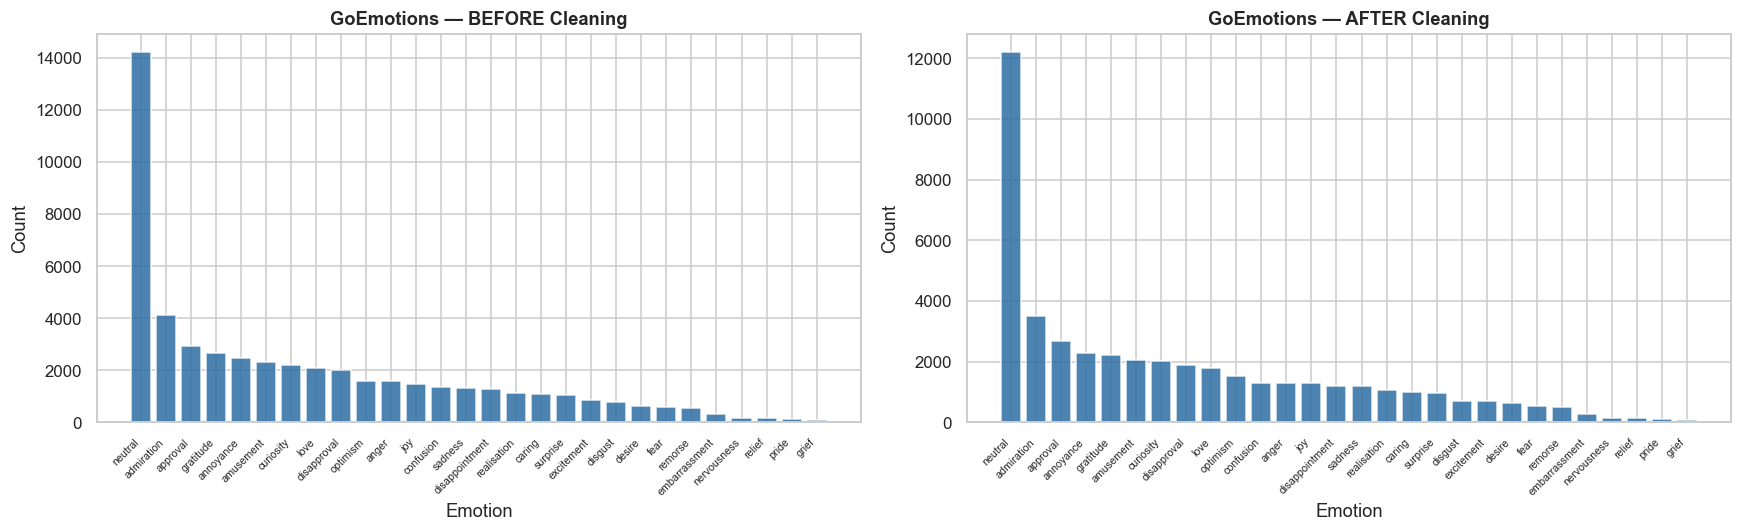

Total before  : 54,263
Total after   : 47,642
Overall retention: 87.8%


In [13]:
# ── After-cleaning distribution ──────────────────────────────────
label_counts_after = Counter()
for labels in cleaned['train']['labels']:
    for lbl in labels:
        label_counts_after[LABEL_NAMES[lbl]] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts_dict, title_sfx in [
    (axes[0], dict(sorted_counts), 'BEFORE'),
    (axes[1], dict(sorted(label_counts_after.items(),
                          key=lambda x: x[1], reverse=True)), 'AFTER')
]:
    names = list(counts_dict.keys())
    vals  = list(counts_dict.values())
    ax.bar(names, vals, color='#2E6DA4', edgecolor='white', alpha=0.85)
    ax.set_title(f'GoEmotions — {title_sfx} Cleaning',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('figures/01c_go_emotions_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
total_before = sum(s['original'] for s in all_stats.values())
total_after  = sum(len(cleaned[s]['texts']) for s in cleaned)
print(f'Total before  : {total_before:,}')
print(f'Total after   : {total_after:,}')
print(f'Overall retention: {total_after/total_before*100:.1f}%')

## 1.6 Save Cleaned Dataset

In [14]:
from datasets import Dataset, DatasetDict

ds_cleaned = DatasetDict({
    split: Dataset.from_dict({
        'text':   cleaned[split]['texts'],
        'labels': cleaned[split]['labels'],
    })
    for split in ['train', 'validation', 'test']
})

ds_cleaned.save_to_disk('data/cleaned/go_emotions')
print('Saved to data/cleaned/go_emotions')
print(ds_cleaned)

# Push to HuggingFace Hub (replace with your username)
ds_cleaned.push_to_hub('AmiruMallawarachchi/mindlens-go-emotions-cleaned')
print('\n✓ GoEmotions preprocessing complete.')

Saving the dataset (0/1 shards):   0%|          | 0/38126 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4756 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4760 [00:00<?, ? examples/s]

Saved to data/cleaned/go_emotions
DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 38126
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 4756
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 4760
    })
})


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.



✓ GoEmotions preprocessing complete.


## 1.7 Preprocessing Summary

| Step | Problem | Fix | Impact |
|------|---------|-----|--------|
| 1 | URLs in text | Regex removal | −noise tokens |
| 2 | HTML entities (&amp;) | Regex decode | −split tokens |
| 3 | [removed]/[deleted] | Regex removal | −empty examples |
| 4 | Edit/update tails | Regex removal | −label mismatch |
| 5 | Under 5 words | Filter | −uninformative examples |
| 6 | Duplicates | MD5 dedup | −inflated metrics |
| 7 | 74× class imbalance | Class weights | +model learns rare emotions |

**Retention rate: 87.8%** — high retention indicates the dataset was already relatively clean. The main issues were class imbalance and minor text noise.

**Class weights are saved** to `data/go_emotions_class_weights.json` and will be loaded into the trainer in `02_emotion_classifier.ipynb`.